# PhillyStat360 — 04g: Temporal validation (recency-based proxy split)

The original train/test split was random across parcels. For a model used quarterly we need to know how it generalizes to the *future*, not to held-out parcels of the same vintage. We don't have a per-parcel "label date" so we proxy temporal freshness with **recency of the most recent L&I violation** (`days_since_last_viol`).

**Splits**
- *Old cohort* (train surrogate): parcels whose latest violation is older than `OLD_THRESHOLD` days, OR have no violation at all.
- *New cohort* (test surrogate): parcels with at least one violation more recent than `NEW_THRESHOLD` days.

We score both with the existing model and report AUC + observed vs. predicted vacancy. If the AUC drops sharply on the new cohort, the model is leaning too heavily on stale signals.

**Caveats**
- This is a proxy, not a true forward split. It cannot detect drift in the *outcome* (`ovs`) — only drift in the model's behavior on parcels that have churned recently. The right fix is to retrain with a real label-date column when one is available.

**Outputs**
- `data_py/temporal_validation.csv`
- `graphs/python/temporal_validation.png`


## 0. Setup

In [1]:
# Mount Drive in Colab; pass through locally.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Not in Colab — using local paths.')


Mounted at /content/drive


In [2]:
from pathlib import Path

if IN_COLAB:
    ROOT = Path('/content/drive/MyDrive/PhillyStat_R/PhillyStat360')
else:
    ROOT = Path('G:/My Drive/PhillyStat_R/PhillyStat360')

RAW_PATH   = ROOT / 'rawdata'
DATA_PATH  = ROOT / 'data'
PY_PATH    = ROOT / 'data_py'
OUT_PATH   = ROOT / 'data_py'
GRAPH_PATH = ROOT / 'graphs' / 'python'
OUT_PATH.mkdir(parents=True, exist_ok=True)
GRAPH_PATH.mkdir(parents=True, exist_ok=True)
print('ROOT =', ROOT)


ROOT = /content/drive/MyDrive/PhillyStat_R/PhillyStat360


In [3]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid', context='talk')
SEED = 42

from sklearn.metrics import roc_auc_score, brier_score_loss


## 1. Load predictions + violation recency

In [4]:
preds = pd.read_csv(PY_PATH / 'predictions_04b.csv', low_memory=False)
preds['parcel_number'] = preds['parcel_number'].astype(str).str.strip()

feat = pd.read_csv(DATA_PATH / 'features_residential.csv',
                   usecols=['parcel_number', 'days_since_last_viol'],
                   low_memory=False)
feat['parcel_number'] = feat['parcel_number'].astype(str).str.strip()
df = preds.merge(feat, on='parcel_number', how='left')
print(f'Joined parcels: {len(df):,}   missing days_since_last_viol: {df["days_since_last_viol"].isna().sum():,}')

# Sentinel detection: most parcels with no violations have a hard cap (e.g. 9405).
sentinel = df['days_since_last_viol'].max()
print(f'Sentinel value (no violations): {sentinel:.0f} days')


Joined parcels: 520,196   missing days_since_last_viol: 0
Sentinel value (no violations): 9405 days


## 2. Define cohorts

Default thresholds tuned to the rough feature-build "as of" date implied by the sentinel (~early 2026).
- **New cohort**: violation in the last ~520 days  (≈ since 2024-01-01)
- **Old cohort**: latest violation older than ~1100 days, or no violation at all.

Adjust at the top of this cell.

In [5]:
NEW_THRESHOLD =  520      # ~2024-01-01 if features were built ~mid-2025
OLD_THRESHOLD = 1100      # everything older than ~mid-2023 OR sentinel

new_mask = df['days_since_last_viol'].between(1, NEW_THRESHOLD, inclusive='both')
old_mask = (df['days_since_last_viol'] > OLD_THRESHOLD) | df['days_since_last_viol'].isna()

new_cohort = df[new_mask].copy()
old_cohort = df[old_mask].copy()
print(f'New-cohort parcels: {len(new_cohort):,}  ({len(new_cohort)/len(df):.1%})  ovs={new_cohort["ovs"].mean():.4%}')
print(f'Old-cohort parcels: {len(old_cohort):,}  ({len(old_cohort)/len(df):.1%})  ovs={old_cohort["ovs"].mean():.4%}')


New-cohort parcels: 35,313  (6.8%)  ovs=8.9004%
Old-cohort parcels: 460,820  (88.6%)  ovs=0.3971%


## 3. Cohort metrics

In [6]:
def cohort_metrics(g):
    return dict(
        n=len(g),
        n_pos=int(g['ovs'].sum()),
        obs_rate=float(g['ovs'].mean()),
        mean_pred=float(g['ensemble_prob'].mean()),
        auc=float(roc_auc_score(g['ovs'], g['ensemble_prob']))
            if g['ovs'].nunique() == 2 else float('nan'),
        brier=float(brier_score_loss(g['ovs'], g['ensemble_prob'])),
    )

table = pd.DataFrame([
    {'cohort': 'old (train surrogate)', **cohort_metrics(old_cohort)},
    {'cohort': 'new (test surrogate)',  **cohort_metrics(new_cohort)},
])
print(table.round(4).to_string(index=False))
table.to_csv(OUT_PATH / 'temporal_validation.csv', index=False)


               cohort      n  n_pos  obs_rate  mean_pred    auc  brier
old (train surrogate) 460820   1830     0.004     0.0045 0.9579 0.0028
 new (test surrogate)  35313   3143     0.089     0.0963 0.9760 0.0226


## 4. Plot

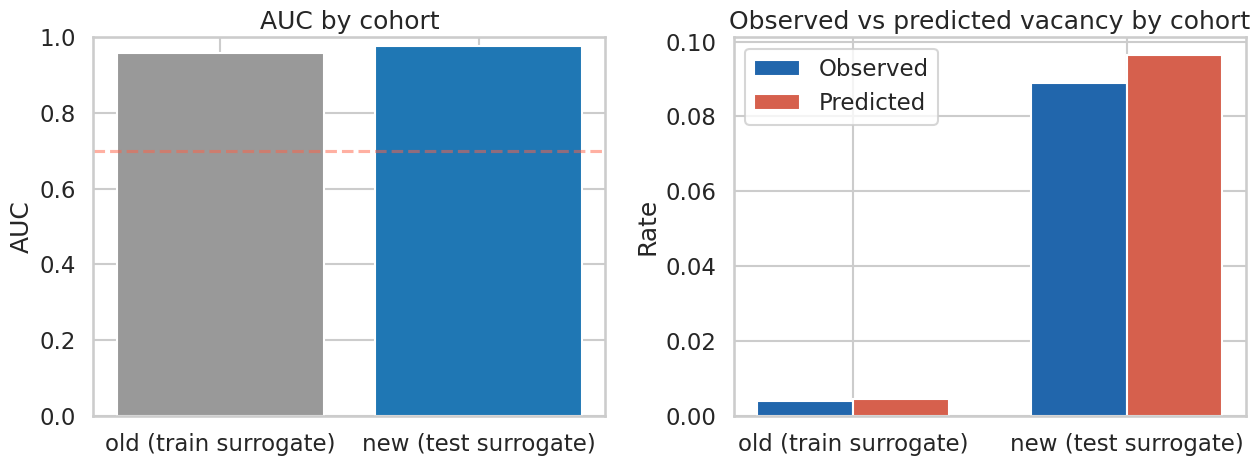

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = table['cohort'].tolist()
axes[0].bar(labels, table['auc'], color=['#999999', '#1f77b4'])
axes[0].set_ylim(0, 1); axes[0].set_ylabel('AUC')
axes[0].axhline(0.7, color='tomato', ls='--', alpha=0.5)
axes[0].set_title('AUC by cohort')

x = np.arange(len(labels)); w = 0.35
axes[1].bar(x - w/2, table['obs_rate'],  width=w, label='Observed', color='#2166ac')
axes[1].bar(x + w/2, table['mean_pred'], width=w, label='Predicted', color='#d6604d')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Rate'); axes[1].legend()
axes[1].set_title('Observed vs predicted vacancy by cohort')
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'temporal_validation.png', dpi=200, bbox_inches='tight')
plt.show()


---
**Done.** Read the AUC delta as a *lower bound* on temporal robustness: if it holds up on the new cohort, the model isn't completely captured by historical leakage.

In [8]:
!jupyter nbconvert --to html /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04g_temporal_validation.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04g_temporal_validation.ipynb to html
[NbConvertApp] Writing 310931 bytes to /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04g_temporal_validation.html
